# Create positions from tissue boundaries

Builds the FOV scanning positions for one or more tissue sections on a coverslip,
from `boundary_positions*.txt`/`hole*.txt` files in
`positions/boundaries/{manual,from_mosaic}/`. Those files can come from either:
drawing them by hand (put them in `positions/boundaries/manual/`), or running
`02_create_boundary_from_mosaic.ipynb` first to derive them automatically from a
Steve low-mag mosaic (writes to `positions/boundaries/from_mosaic/`) — both feed
this notebook identically; `BOUNDARY_SOURCE` below picks which one to read.

**Grid method** (`GRID_METHOD`, default `"regular"`) and **offset
optimization** (`OPTIMIZE_OFFSET`, default `False`) are both forwarded to
`build_reduced_fov_path` (mirrors `segment_mosaic_tissue`'s single-function
design, applied to FOV-path generation instead of boundary derivation):
`GRID_METHOD="regular"` builds a single regular lattice per boundary,
snake-ordered by `SCAN_DIRECTION`; `"irregular"` instead builds a
single-axis-adaptive grid: `IRREGULAR_FIXED_AXIS` stays a regular lattice,
the other axis is rebuilt independently per row/column, snug to that
row/column's own local tissue extent -- fewer FOVs on an irregularly-shaped
tissue (holes, notches, tapering edges), at the cost of a weaker (not
globally phase-locked) cross-axis overlap margin. `OPTIMIZE_OFFSET=True`
additionally searches the grid's phase (regular) or fixed-axis phase
(irregular) for the one needing fewest FOVs. See
`acquisition/positions.py`'s own "Irregular (single-axis-adaptive) grid"
section and `notebooks/tests/create_positions/02_sweep_reduced_fov_path_combinations.ipynb`
for the combination sweep these defaults are based on -- plain `regular`,
no offset optimization, won on a real benchmark boundary at both 60X and
40X; offset optimization and redundant-FOV removal (below) were found to
be non-additive (each on its own saves more than both combined), so
`OPTIMIZE_OFFSET` defaults off and redundant-FOV removal carries the load.

**Tissue count** (auto-detected from the filenames in the resolved boundary folder):
- **multi**  — `tissue_{t}_boundary_positions_{b}.txt`: several tissue sections,
  each possibly split across several boundary files.
- **single** — `boundary_positions_{b}.txt`: one tissue, several boundaries.
- **legacy** — a lone `boundary_positions.txt`: one boundary (original behaviour).

**Boundaries per tissue.** A tissue can have one or more boundary files; either
way this notebook always builds ONE single continuous grid per tissue -- a
tissue's own boundaries are simply concatenated in acquisition order, each
closing its own loop back near its start.

**Redundant-FOV removal** (`REMOVE_REDUNDANT_FOVS`, default `True`): a FOV
is "fully redundant" if every bit of tissue it touches is already covered
by some other FOV in the grid -- dropping it loses no real coverage (see
`find_fully_redundant_fovs`'s own docstring; shows up mainly at narrow
tissue tips/corners). On by default for a free FOV-count reduction at zero
coverage cost -- see
`notebooks/tests/decrease_fov_number/04_find_fully_redundant_fovs.ipynb`
for the validated numbers this is based on. The overview plot ("FOV layout")
highlights redundant FOVs in red when this is on; a second plot right after
it shows the final grid with them actually removed.

**Subsets** (optional whitelist regions, `positions/boundaries/<source>/subset1.txt`,
`subset2.txt`, etc. -- same comma-separated `x,y` format as `boundary_positions*.txt`/
`hole*.txt`). When present, only FOVs overlapping the union of every `subset*.txt`
are kept -- the opposite of a hole (which excludes instead of restricts). Subsets
are global, like holes: every one applies to every boundary. Handy for re-imaging
or restricting acquisition to part of an already-drawn tissue boundary without
redrawing it.

**Outputs** (written to `positions/`, with `SAMPLE = POSITIONS_TAG`, i.e.
`SAMPLE_NAME` — the TRUE top-level experiment id auto-detected via
`resolve_sample_identity` — with `_{IMAGING_DIR}` appended in a split layout,
e.g. `LT058_sample_07_merfish`, so a sibling acquisition of the same sample
(e.g. `lineage_tracing/merfish` vs `lineage_tracing/lineage`) never writes an
identically-named positions file. NOT `SAMPLE_DIR.name`, which is only this
acquisition's own local folder name once split into sibling acquisition-type
subfolders):
- the combined acquisition-order file Dave/notebook 03 actually use:
  `positions_{SAMPLE}.txt` (every tissue's FOVs concatenated into one grid)
- per-tissue FOV-only files, informational only: `positions_{SAMPLE}_T{t}.txt`
  (multi tissue count only)

It also creates the `data/` subfolders for the layout (`mosaic10x`, and either
`tissue_{t}/{cells,hybs}` or top-level `{cells,hybs}`).


## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
from shapely.geometry import Polygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MERCI_DIR  = Path(os.getcwd()).parent.parent.parent   # MERci/ (notebook lives in MERci/notebooks/before_imaging/regular/)
SAMPLE_DIR = MERCI_DIR.parent                  # experiment root, e.g. LT048_sample_18/
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.io               import save_positions_array
from MERci.common.experiment_info  import resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs     import get_fov_geometry
from MERci.visualization import get_merci_figures_dir
from MERci.acquisition.positions   import (
    discover_boundary_files, resolve_boundary_dir, resolve_boundaries_source_dir,
    load_boundary_polygon, load_hole_polygons_all_sources, load_subset_polygons,
    group_boundaries_by_path_mode, merge_union_tissue_boundaries,
    build_reduced_fov_path, get_path_stats,
    find_fully_redundant_fovs,
)

## 2 — Parameters

In [2]:
POSITIONS_DIR = SAMPLE_DIR / "positions"
DATA_DIR      = SAMPLE_DIR / "data"
POSITIONS_DIR.mkdir(parents=True, exist_ok=True)
figures_dir = get_merci_figures_dir(SAMPLE_DIR, "before_imaging", "02_create_positions_from_boundaries")

# SAMPLE_NAME/POSITIONS_TAG -- see this notebook's own intro cell's "Outputs" note.
SAMPLE_NAME, IMAGING_DIR = resolve_sample_identity(MERCI_DIR)
POSITIONS_TAG = positions_file_tag(SAMPLE_NAME, IMAGING_DIR)

# ── Grid / FOV geometry ──────────────────────────────────────────────────
MICROSCOPE           = "ST2"   # MF2-MF5: 0.108 um/px, 2048 px | MFX/ST2: 0.0878 um/px, 2304 px
OBJECTIVE             = "60X"   # only ST2 currently supports more than one ("60X" 0.0878 um/px | "40X" 0.1317 um/px, scaled placeholder); every other microscope has only "60X"
pixel_size_um, image_size_px = get_fov_geometry(MICROSCOPE, OBJECTIVE)  # geometry from microscope + objective
non_overlap_fraction = 0.9

step_size_um = pixel_size_um * image_size_px * non_overlap_fraction
fov_size_um  = pixel_size_um * image_size_px

# ── Scanning options ──────────────────────────────────────────────────────
SCAN_DIRECTION       = "vertical"   # boustrophedon direction within each boundary

# regular (regular square lattice) | irregular (one axis regular, the other
# adaptive to local tissue extent -- see acquisition/positions.py's own
# "Irregular (single-axis-adaptive) grid" section for the full rationale)
GRID_METHOD          = "regular"   # "regular" | "irregular"
IRREGULAR_FIXED_AXIS  = "x"          # "x" or "y" -- only used when GRID_METHOD == "irregular"

# Search the grid's phase (regular) / fixed-axis phase (irregular) for the
# one needing fewest FOVs (see build_reduced_fov_path's own docstring). Off
# by default: found non-additive with REMOVE_REDUNDANT_FOVS below on a real
# benchmark boundary (each alone saves more than both combined) -- see
# notebooks/tests/create_positions/02_sweep_reduced_fov_path_combinations.ipynb.
OPTIMIZE_OFFSET      = False

# Drop FOVs whose entire tissue overlap is already covered by some other FOV
# (see this notebook's own intro cell) -- on by default for a free FOV-count
# reduction at zero coverage cost.
REMOVE_REDUNDANT_FOVS = True

# Every tissue's own boundaries (one or more) are concatenated into a single
# continuous grid, each closing its own loop back near its start -- see this
# notebook's own intro cell.
def tissue_path_mode(t):
    return "legacy"


## 3 — Discover boundary layout

In [3]:
# Boundary inputs live under positions/boundaries/{manual,from_mosaic}/.
# BOUNDARY_SOURCE = None auto-picks whichever of the two has files (preferring
# from_mosaic), so this notebook doesn't need to be told which upstream method
# you used; set it explicitly ("manual" or "from_mosaic") to override.
BOUNDARY_SOURCE = None
SOURCE_DIR, BOUNDARY_SOURCE = resolve_boundaries_source_dir(POSITIONS_DIR, BOUNDARY_SOURCE)

# If the resolved source has no boundary files yet (e.g. a fresh experiment),
# fall back to a bundled EXAMPLE dataset under MERci/data/positions/examples/
# so the notebook can still be run and tested. EXAMPLE_LAYOUT selects which
# example set to use. "lineage_tracing_mosaic" (default for this acquisition
# type) is a real, complex single-tissue boundary + 7 holes auto-derived via
# segment_mosaic_tissue from the same bundled mosaic canvas
# 02_create_boundary_from_mosaic.ipynb falls back to -- so the two notebooks'
# examples stay consistent with each other.
EXAMPLE_LAYOUT = "lineage_tracing_mosaic"     # "legacy" | "single" | "multi" | "lineage_tracing_mosaic"
EXAMPLE_ROOT   = MERCI_DIR / "data" / "positions" / "examples"
BOUNDARY_DIR, USING_EXAMPLE = resolve_boundary_dir(SOURCE_DIR, EXAMPLE_ROOT, EXAMPLE_LAYOUT)
if USING_EXAMPLE:
    # SOURCE_DIR has no boundary files: copy the example boundary + hole inputs
    # into it so the experiment folder is self-contained and notebook 03
    # (which reads the same resolved source directory) finds them. Idempotent:
    # once copied, resolve_boundary_dir returns SOURCE_DIR and this branch is
    # skipped.
    import shutil
    SOURCE_DIR.mkdir(parents=True, exist_ok=True)
    copied = [f.name for f in sorted(BOUNDARY_DIR.glob("*.txt"))]
    for fname in copied:
        shutil.copy2(BOUNDARY_DIR / fname, SOURCE_DIR / fname)
    print(f"WARNING: no boundary files in {SOURCE_DIR};")
    print(f"         copied {len(copied)} example input(s) from '{EXAMPLE_LAYOUT}' -> "
          f"boundaries/{BOUNDARY_SOURCE}/: {copied}\n")
    BOUNDARY_DIR = SOURCE_DIR

boundaries, MODE = discover_boundary_files(BOUNDARY_DIR)
tissues          = sorted({b.tissue for b in boundaries})
n_boundaries     = len(boundaries)

print(f"SAMPLE_DIR     : {SAMPLE_DIR}")
print(f"SAMPLE_NAME    : {SAMPLE_NAME}")
print(f"POSITIONS_TAG  : {POSITIONS_TAG}")
print(f"BOUNDARY_SOURCE: {BOUNDARY_SOURCE}")
print(f"BOUNDARY_DIR   : {BOUNDARY_DIR}")
print(f"Objective      : {OBJECTIVE} ({pixel_size_um:.4f} um/px)")
print(f"Step size      : {step_size_um:.1f} um")
print(f"FOV size       : {fov_size_um:.1f} um")
print(f"Grid method    : {GRID_METHOD}" + (f" (fixed_axis={IRREGULAR_FIXED_AXIS})" if GRID_METHOD == "irregular" else ""))
print(f"Offset optimization  : {OPTIMIZE_OFFSET}")
print(f"Redundant-FOV removal: {REMOVE_REDUNDANT_FOVS}")
print(f"\nLayout mode   : {MODE}   ({len(tissues)} tissue(s), {n_boundaries} boundary file(s))")
print(f"Boundaries in acquisition order:")
for b in boundaries:
    print(f"  {b.label or '(single)':8s}  <- {b.path.name}")
print(f"\nPer-tissue path mode:")
for t in tissues:
    n_b = sum(1 for b in boundaries if b.tissue == t)
    print(f"  tissue {t}: {tissue_path_mode(t):8s} ({n_b} boundary file(s))")


SAMPLE_DIR     : /n/home06/lsepulvedaduran/251225_LT027_saving_time
SAMPLE_NAME    : 251225_LT027_saving_time
POSITIONS_TAG  : 251225_LT027_saving_time
BOUNDARY_SOURCE: from_mosaic
BOUNDARY_DIR   : /n/home06/lsepulvedaduran/251225_LT027_saving_time/positions/boundaries/from_mosaic
Objective      : 60X (0.0878 um/px)
Step size      : 182.1 um
FOV size       : 202.3 um
Grid method    : regular
Offset optimization  : False
Redundant-FOV removal: True

Layout mode   : single   (1 tissue(s), 4 boundary file(s))
Boundaries in acquisition order:
  B1        <- boundary_positions_1.txt
  B2        <- boundary_positions_2.txt
  B3        <- boundary_positions_3.txt
  B4        <- boundary_positions_4.txt

Per-tissue path mode:
  tissue 1: legacy   (4 boundary file(s))


## 4 — Load boundaries, build FOV paths, assemble segments

In [4]:
# ── Load boundaries + holes + subsets, build per-boundary FOV paths ──────
# Holes/subsets are global: every hole*.txt/subset*.txt applies to every
# boundary. Subsets are an optional whitelist -- when present, only FOVs
# overlapping their union are kept (the opposite of a hole). Holes also
# merge in any from boundaries/manual/ even when BOUNDARY_SOURCE is
# "from_mosaic" (see load_hole_polygons_all_sources).
holes   = load_hole_polygons_all_sources(POSITIONS_DIR, BOUNDARY_DIR)
subsets = load_subset_polygons(BOUNDARY_DIR)
print(f"Loaded {len(holes)} hole polygon(s), {len(subsets)} subset polygon(s) (applied to all boundaries)")

boundary_polys = [load_boundary_polygon(b.path) for b in boundaries]

# "union"-mode tissues: merge their own multiple boundary pieces into ONE
# shared-grid pseudo-boundary up front, so every per-boundary/grouping/
# plotting step below (which already only has to handle "one boundary per
# tissue") needs no further changes -- see merge_union_tissue_boundaries's
# docstring for why this produces a single continuous grid+snake across
# every piece instead of "legacy" mode's per-piece grids concatenated.
boundaries, boundary_polys = merge_union_tissue_boundaries(
    boundaries, boundary_polys, MODE, tissue_path_mode
)

# Group consecutive same-tissue boundaries into acquisition-order segments
# (merges each tissue's own boundaries into one, since tissue_path_mode is
# always "legacy" here) -- see group_boundaries_by_path_mode's own docstring
# for the general grouping rule this notebook always takes the "legacy"
# branch of.
groups = group_boundaries_by_path_mode(boundaries, MODE, tissue_path_mode)

def _boundary_return_side(spec):
    # Every boundary closes its own loop back near its start (see
    # close_scanning_path) -- always true now that every tissue uses a
    # single continuous grid (see this notebook's own intro cell).
    return "top"

if GRID_METHOD not in ("regular", "irregular"):
    raise ValueError(f"GRID_METHOD must be 'regular' or 'irregular', got {GRID_METHOD!r}")

# GRID_METHOD == "irregular": _boundary_return_side's literal "top" is only
# the correct closing side for the REGULAR grid -- the irregular grid's own
# natural side depends on IRREGULAR_FIXED_AXIS (see determine_return_side's
# docstring), so only its "does this boundary need closing at all" decision
# is reused; return_side="auto" then picks the actual side itself.
#
# remove_redundant_fovs=False here: this builds the RAW per-boundary grid
# only (needed as-is for the overview/mosaic-overlay plots below); the
# actual redundant-FOV removal is done once, globally across every
# boundary's concatenated path, in section 5 below.
boundary_paths = []
for spec, poly in zip(boundaries, boundary_polys):
    needs_closing = _boundary_return_side(spec) is not None
    result = build_reduced_fov_path(
        poly, holes, step_size_um, fov_size_um,
        irregular_grid  = GRID_METHOD == "irregular",
        optimize_offset = OPTIMIZE_OFFSET,
        direction       = SCAN_DIRECTION,
        fixed_axis      = IRREGULAR_FIXED_AXIS,
        return_side     = ("auto" if GRID_METHOD == "irregular" else "top") if needs_closing else None,
        subset_polygons = subsets,
        remove_redundant_fovs = False,
    )
    boundary_paths.append(result.coords)
for spec, path in zip(boundaries, boundary_paths):
    if len(path) == 0:
        raise ValueError(
            f"Boundary {spec.label or spec.path.name} produced 0 FOVs — "
            f"check the boundary file and grid geometry."
        )

# Every tissue's own boundaries are assumed to be close/contiguous enough
# that concatenating them needs no bridging -- warn if that assumption
# looks wrong (a gap much bigger than a normal grid step), since nothing
# images that gap.
GAP_WARN_FACTOR = 5.0
for group in groups:
    for a_idx, b_idx in zip(group.boundary_indices, group.boundary_indices[1:]):
        gap = float(np.linalg.norm(boundary_paths[a_idx][-1] - boundary_paths[b_idx][0]))
        if gap > GAP_WARN_FACTOR * step_size_um:
            print(f"WARNING: tissue {group.tissue} boundaries "
                  f"{boundaries[a_idx].label or '(single)'} -> {boundaries[b_idx].label or '(single)'} "
                  f"are {gap:.0f} um apart ({gap / step_size_um:.1f}x step) -- "
                  f"nothing images this gap.")

# ── Assemble the ordered segment list ────────────────────────────────────
# Each group above becomes one segment (its boundaries' coordinates
# concatenated in order, single-element unless merged under "legacy").
# Segments are concatenated directly into one single continuous grid below,
# regardless of tissue count.
segments = [
    {"tissue": g.tissue, "label": g.label,
     "coords": np.concatenate([boundary_paths[k] for k in g.boundary_indices], axis=0)}
    for g in groups
]

print(f"\n{len(segments)} boundary segment(s):")
for seg in segments:
    print(f"  {(seg['label'] or '(single)'):12s} [tissue {seg['tissue']}]: {len(seg['coords'])} FOVs")


hole1.txt produced an invalid Shapely polygon – skipping.


hole2.txt produced an invalid Shapely polygon – skipping.


hole3.txt produced an invalid Shapely polygon – skipping.


Loaded 40 hole polygon(s), 0 subset polygon(s) (applied to all boundaries)



1 boundary segment(s):
  (single)     [tissue 1]: 1111 FOVs


## 5 — Detect fully-redundant FOVs

In [5]:
# ── Build full_path (acquisition order) and detect fully-redundant FOVs ──
# (see REMOVE_REDUNDANT_FOVS in the Parameters section above, and
# find_fully_redundant_fovs's own docstring). Computed here, before the
# plots below, so both the highlighted-overview plot and the after-removal
# plot can use it; `redundant` stays None when the toggle is off.
full_path = np.concatenate([s["coords"] for s in segments], axis=0)

if REMOVE_REDUNDANT_FOVS:
    effective_tissue = unary_union(boundary_polys)
    if holes:
        effective_tissue = effective_tissue.difference(unary_union(holes))
    redundant = find_fully_redundant_fovs(full_path, effective_tissue, fov_size_um)
    print(f"Redundant-FOV removal: {len(redundant.detected)} detected, "
          f"{len(redundant.removed)} safe to drop together "
          f"({redundant.n_passes} pass(es)), "
          f"uncovered tissue after removal: {redundant.uncovered_area_um2:.4f} um^2")
    print(f"FOVs: {len(full_path)} -> {len(redundant.kept_coords)}")
else:
    redundant = None


Redundant-FOV removal: 157 detected, 97 safe to drop together (2 pass(es)), uncovered tissue after removal: 0.0000 um^2
FOVs: 1111 -> 1014


## 6 — Overview plot: FOV layout (redundant FOVs highlighted)

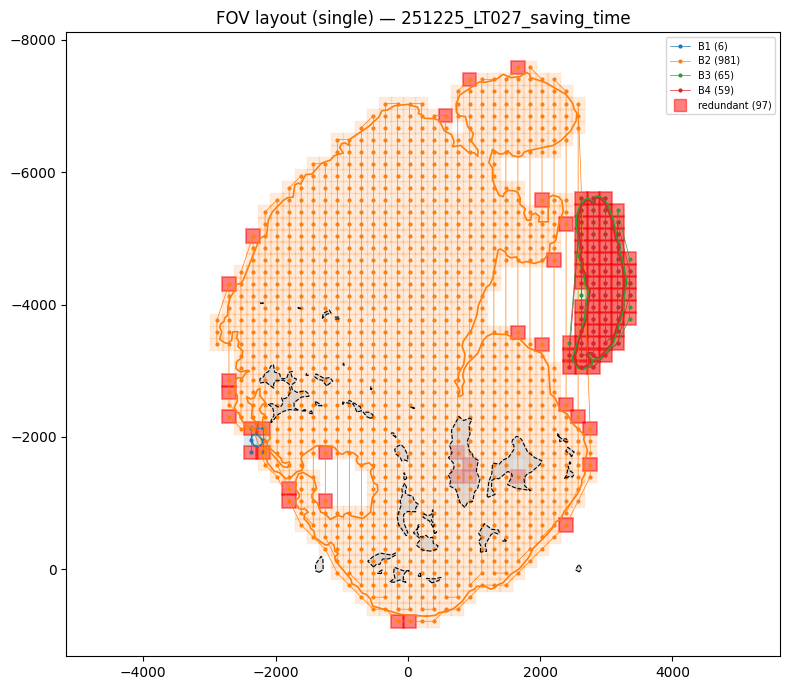

In [6]:
# ── Overview plot: all boundaries and their FOVs -- redundant FOVs (see
# the previous section) are highlighted in red when REMOVE_REDUNDANT_FOVS
# is on ──
half   = fov_size_um / 2
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 7))
fov_idx = 0
for i, (spec, poly, path) in enumerate(zip(boundaries, boundary_polys, boundary_paths)):
    c = colors[i % len(colors)]
    ax.plot(*poly.exterior.xy, "-", lw=1.2, color=c)
    for x, y in path:
        is_redundant = redundant is not None and fov_idx in redundant.removed
        ax.add_patch(mpatches.Rectangle(
            (x - half, y - half), fov_size_um, fov_size_um,
            lw=1.2 if is_redundant else 0.3,
            edgecolor="red" if is_redundant else c,
            facecolor="red" if is_redundant else c,
            alpha=0.5 if is_redundant else 0.15,
        ))
        fov_idx += 1
    ax.plot(path[:, 0], path[:, 1], "-o", ms=2, lw=0.5, color=c,
            label=f"{spec.label or 'boundary'} ({len(path)})")

for hole in holes:
    ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
    ax.plot(*hole.exterior.xy, "k--", lw=0.8)

for subset in subsets:
    ax.plot(*subset.exterior.xy, "g--", lw=0.8)

if redundant is not None and redundant.removed:
    ax.plot([], [], "s", color="red", alpha=0.5, ms=8,
            label=f"redundant ({len(redundant.removed)})")

ax.invert_yaxis(); ax.axis("equal")
ax.legend(fontsize=7, loc="best")
plt.title(f"FOV layout ({MODE}) — {SAMPLE_NAME}")
plt.tight_layout()
fig.savefig(figures_dir / f"fov_layout_{POSITIONS_TAG}.png", dpi=150)
plt.show()


## 7 — Overview plot: final grid after redundant-FOV removal

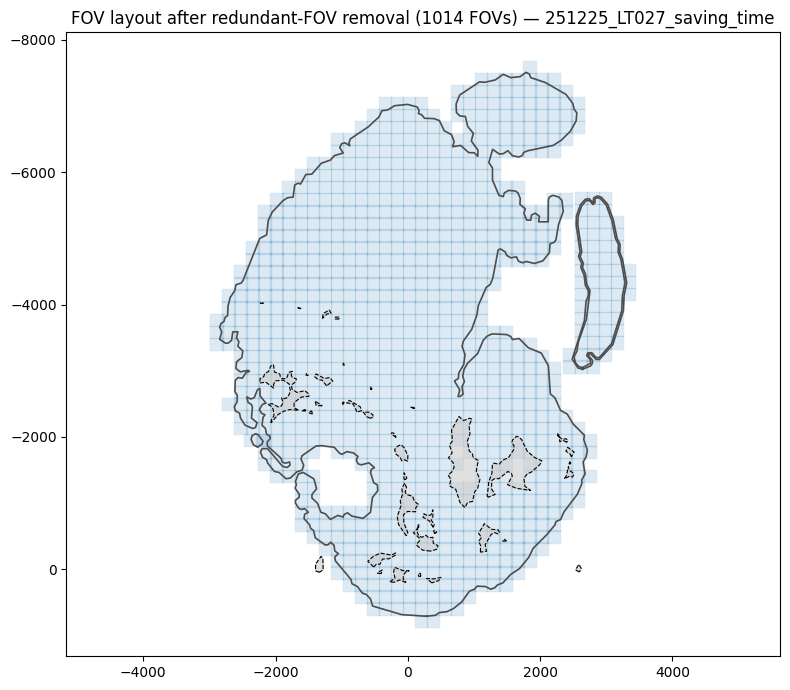

In [7]:
# ── Overview plot: the final grid with redundant FOVs actually removed --
# skipped when REMOVE_REDUNDANT_FOVS is off (nothing was removed, it would
# be identical to the plot above) ──
if redundant is not None:
    half = fov_size_um / 2
    fig, ax = plt.subplots(figsize=(8, 7))
    for poly in boundary_polys:
        ax.plot(*poly.exterior.xy, "-", lw=1.2, color="0.3")
    for x, y in redundant.kept_coords:
        ax.add_patch(mpatches.Rectangle((x - half, y - half), fov_size_um, fov_size_um,
                                        lw=0.3, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.15))
    for hole in holes:
        ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
        ax.plot(*hole.exterior.xy, "k--", lw=0.8)
    for subset in subsets:
        ax.plot(*subset.exterior.xy, "g--", lw=0.8)
    ax.invert_yaxis(); ax.axis("equal")
    plt.title(f"FOV layout after redundant-FOV removal "
              f"({len(redundant.kept_coords)} FOVs) — {SAMPLE_NAME}")
    plt.tight_layout()
    fig.savefig(figures_dir / f"fov_layout_redundant_removed_{POSITIONS_TAG}.png", dpi=150)
    plt.show()
else:
    print("REMOVE_REDUNDANT_FOVS is off -- skipping this plot (nothing was "
          "removed, it would be identical to the plot above).")


## 8 — Verify FOV coverage against the source mosaic (`from_mosaic` boundaries only)

Only meaningful when `BOUNDARY_SOURCE == "from_mosaic"` -- a hand-drawn
boundary has no underlying mosaic image to check FOVs against. Recreates the
flattened mosaic canvas from `02_create_boundary_from_mosaic.ipynb` (cached
under `analysis/cache/` so re-running this notebook doesn't reassemble it
every time) and overlays every generated FOV's footprint directly on top of
the real tissue image -- an FOV that looks empty/background here will very
likely come back empty during acquisition too, which is worth catching now
rather than after the fact.


In [8]:
# ── Recreate the source mosaic image, for FOV-coverage verification ──────
mosaic_canvas = None

if BOUNDARY_SOURCE == "from_mosaic":
    import json
    from MERci.acquisition.mosaic import load_steve_mosaic, assemble_mosaic_canvas, MosaicCanvas

    # Must match whatever 02_create_boundary_from_mosaic.ipynb was actually
    # run with (MOSAIC_DIR/MOSAIC_KEEP_OBJECTIVES/WORKING_PIXEL_UM there), or
    # the recreated image won't line up with the boundary it produced.
    MOSAIC_DIR              = SAMPLE_DIR / "data" / "mosaic10x"
    MOSAIC_NAME             = None       # None = auto-detect the only *.msc file present
    MOSAIC_KEEP_OBJECTIVES  = ["10x"]    # None = keep every objective
    MOSAIC_WORKING_PIXEL_UM = 5.0

    msc_candidates = sorted(MOSAIC_DIR.glob(f"{MOSAIC_NAME or '*'}.msc"))
    if not msc_candidates:
        # Same bundled-example-canvas fallback 02_create_boundary_from_mosaic.ipynb
        # uses (USING_EXAMPLE_MOSAIC there) -- if that's what produced this
        # boundary, recreate the overlay from that canvas instead of skipping it.
        from MERci.acquisition.mosaic import load_mosaic_canvas
        EXAMPLE_CANVAS_PATH = MERCI_DIR / "data" / "mosaic_canvas_examples" / "lineage_tracing" / "canvas.npz"
        if EXAMPLE_CANVAS_PATH.exists():
            mosaic_canvas = load_mosaic_canvas(EXAMPLE_CANVAS_PATH)
            print(f"WARNING: no .msc mosaic manifest in {MOSAIC_DIR}; using the bundled "
                  f"example canvas instead ({EXAMPLE_CANVAS_PATH}).")
            print(f"Canvas: {mosaic_canvas.image.shape[1]}x{mosaic_canvas.image.shape[0]} px "
                  f"at {mosaic_canvas.pixel_size_um:.2f} um/px")
        else:
            print(f"WARNING: no .msc mosaic manifest found in {MOSAIC_DIR}, and no bundled "
                  f"example canvas at {EXAMPLE_CANVAS_PATH} either -- can't recreate the "
                  f"source image. Skipping overlay.")
    else:
        msc_path = msc_candidates[0]

        # Cache the assembled canvas (see NOTEBOOK_GUIDELINES.md #2/#3).
        cache_dir    = SAMPLE_DIR / "analysis" / "cache" / "02_create_positions_from_boundaries"
        cache_dir.mkdir(parents=True, exist_ok=True)
        cache_npz    = cache_dir / "mosaic_canvas.npz"
        cache_params = cache_dir / "mosaic_canvas_params.json"
        params_now = {
            "msc_path": str(msc_path), "msc_mtime": msc_path.stat().st_mtime,
            "keep_objectives": MOSAIC_KEEP_OBJECTIVES, "working_pixel_um": MOSAIC_WORKING_PIXEL_UM,
        }

        cached_ok = False
        if cache_npz.exists() and cache_params.exists():
            with open(cache_params) as fh:
                cached_ok = json.load(fh) == params_now

        if cached_ok:
            npz = np.load(cache_npz)
            mosaic_canvas = MosaicCanvas(
                image=npz["image"], covered=npz["covered"],
                origin_um=tuple(npz["origin_um"]), pixel_size_um=float(npz["pixel_size_um"]),
            )
            print(f"Loaded cached mosaic canvas: {cache_npz}")
        else:
            tiles_all = load_steve_mosaic(msc_path)
            tiles = tiles_all if MOSAIC_KEEP_OBJECTIVES is None else [
                t for t in tiles_all if t.objective_name in MOSAIC_KEEP_OBJECTIVES
            ]
            mosaic_canvas = assemble_mosaic_canvas(tiles, working_pixel_um=MOSAIC_WORKING_PIXEL_UM)
            np.savez_compressed(
                cache_npz, image=mosaic_canvas.image, covered=mosaic_canvas.covered,
                origin_um=np.array(mosaic_canvas.origin_um), pixel_size_um=mosaic_canvas.pixel_size_um,
            )
            with open(cache_params, "w") as fh:
                json.dump(params_now, fh)
            print(f"Assembled + cached mosaic canvas from {len(tiles)} tile(s): {cache_npz}")

        print(f"Canvas: {mosaic_canvas.image.shape[1]}x{mosaic_canvas.image.shape[0]} px "
              f"at {mosaic_canvas.pixel_size_um:.2f} um/px")
else:
    print(f"BOUNDARY_SOURCE={BOUNDARY_SOURCE!r} -- no source mosaic to overlay "
          f"(only applicable when the boundary was derived from a Steve mosaic).")

load_steve_mosaic: '10x' tiles (35) shifted by (x=+420.00, y=+410.00) um [.msc-recorded]
load_steve_mosaic: '60x' tiles (9) shifted by (x=+0.00, y=+0.00) um [.msc-recorded]


Assembled + cached mosaic canvas from 35 tile(s): /n/home06/lsepulvedaduran/251225_LT027_saving_time/analysis/cache/02_create_positions_from_boundaries/mosaic_canvas.npz
Canvas: 1318x1839 px at 5.00 um/px


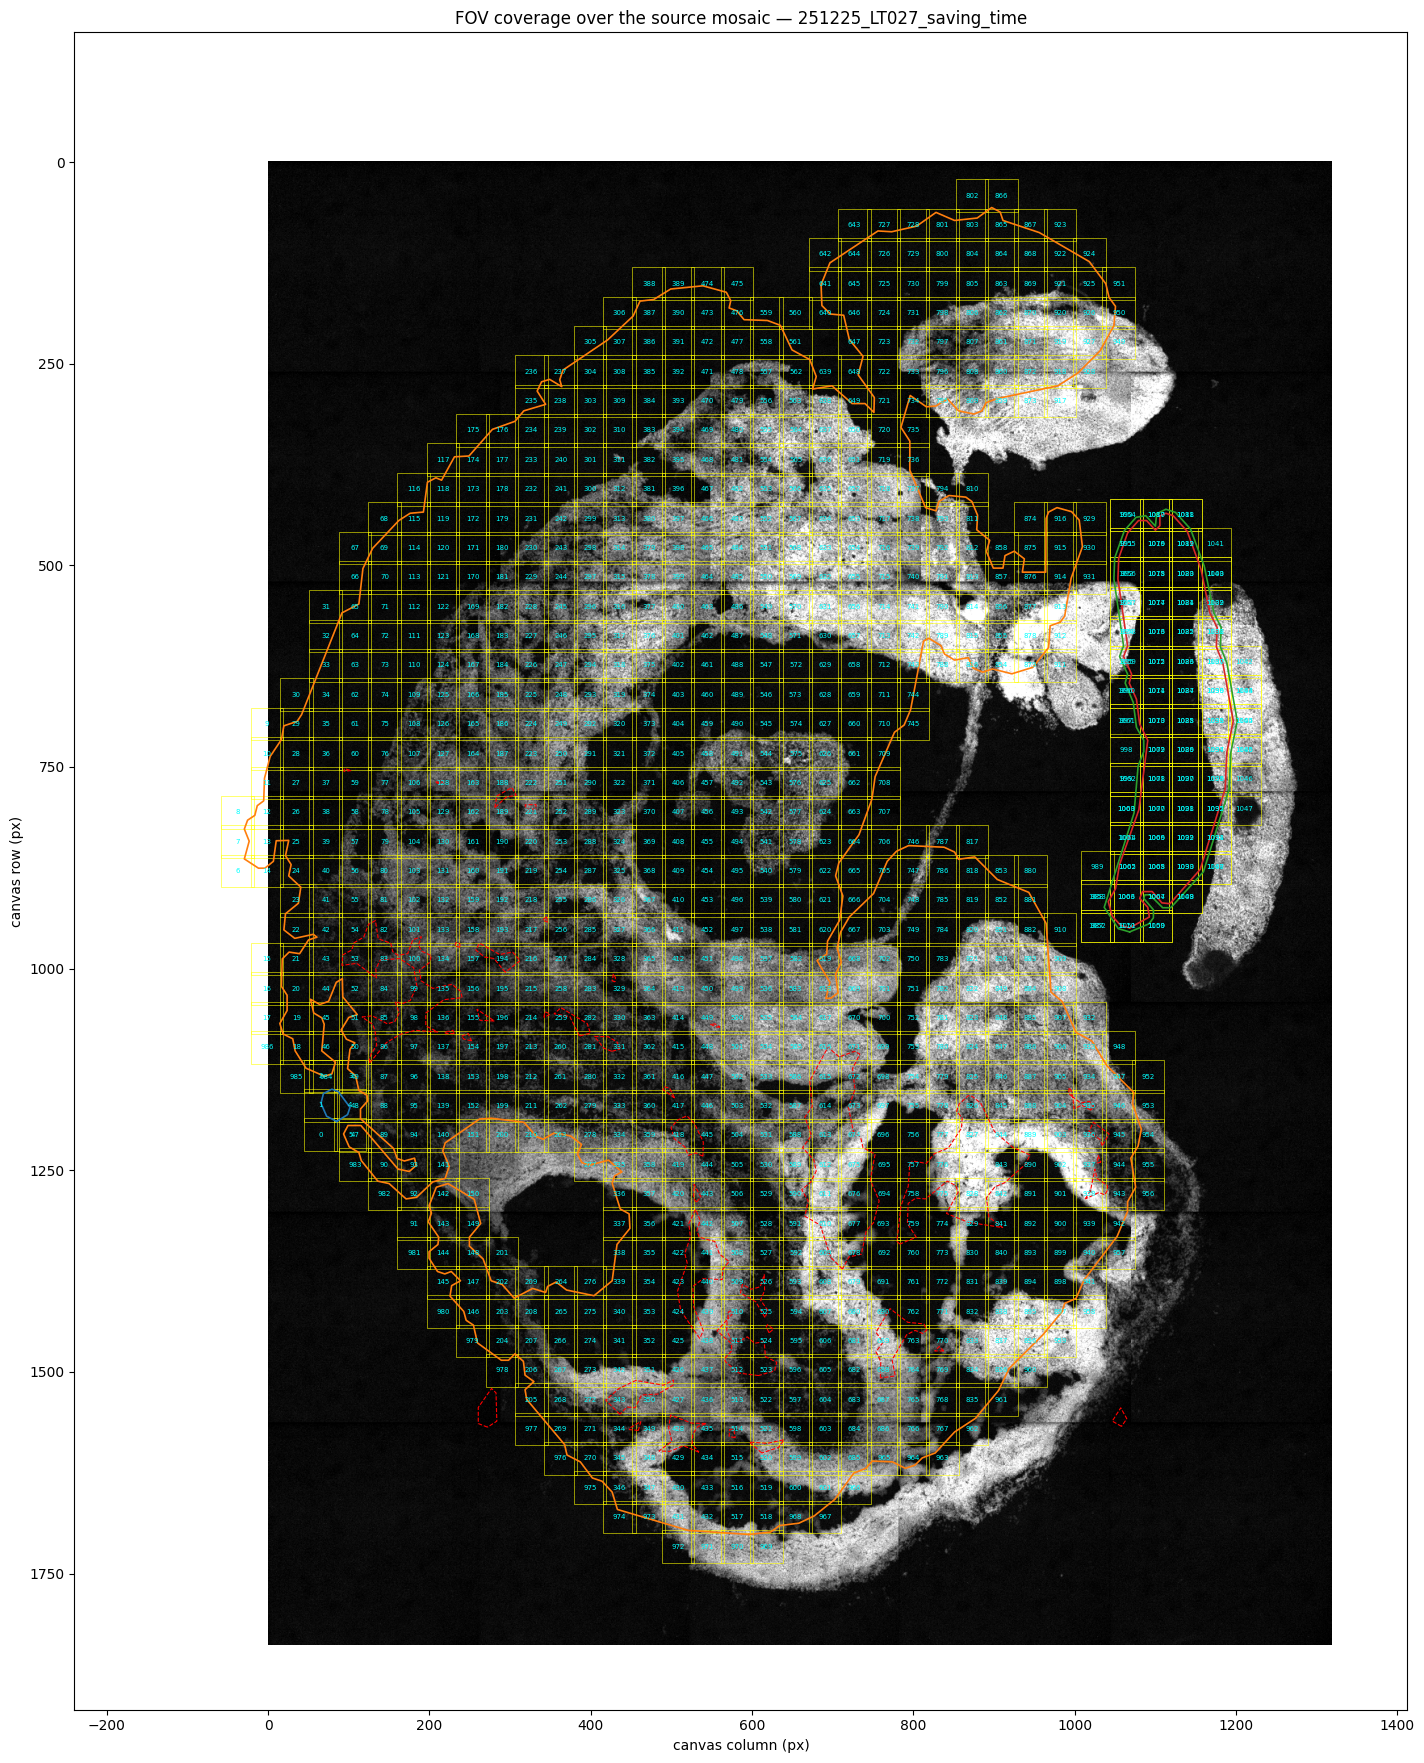

In [9]:
# ── Overlay the generated FOVs on the source mosaic image ────────────────
# 0-based global FOV index (a running counter across every boundary's own
# path, in boundary order, matching what
# this overlay already draws). Non-empty + valid indices here are drawn in
# magenta/bold instead of the default yellow, to spot-check specific FOVs.
selected_FOVs = []

if mosaic_canvas is not None:
    def _um_to_px(x, y):
        return ((np.asarray(x) - mosaic_canvas.origin_um[0]) / mosaic_canvas.pixel_size_um,
                 (np.asarray(y) - mosaic_canvas.origin_um[1]) / mosaic_canvas.pixel_size_um)

    half_px = (fov_size_um / 2) / mosaic_canvas.pixel_size_um

    # Bounding box of every generated FOV (all boundaries), converted to px,
    # to crop the plot to +/- 5 FOVs of margin -- the full mosaic canvas is
    # mostly black background far outside the tissue/boundary region.
    all_px = [_um_to_px(path[:, 0], path[:, 1])[0] for path in boundary_paths]
    all_py = [_um_to_px(path[:, 0], path[:, 1])[1] for path in boundary_paths]
    all_px_flat, all_py_flat = np.concatenate(all_px), np.concatenate(all_py)
    margin_px = 5 * (fov_size_um / mosaic_canvas.pixel_size_um)
    x_min, x_max = all_px_flat.min() - margin_px, all_px_flat.max() + margin_px
    y_min, y_max = all_py_flat.min() - margin_px, all_py_flat.max() + margin_px

    # Size the figure from the CROPPED region's extent in FOV-widths, not a
    # fixed constant, so the per-FOV number stays legible whether the crop
    # covers a handful of FOVs or several hundred (capped so a very large
    # grid doesn't request an unreasonable canvas).
    step_px       = fov_size_um / mosaic_canvas.pixel_size_um
    inch_per_fov  = 0.35
    fig_w = float(np.clip((x_max - x_min) / step_px * inch_per_fov, 8, 60))
    fig_h = float(np.clip((y_max - y_min) / step_px * inch_per_fov, 8, 60))

    covered_vals = mosaic_canvas.image[mosaic_canvas.covered]
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(
        mosaic_canvas.image, cmap="gray",
        vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99),
    )

    n_total_fovs = int(all_px_flat.size)
    invalid_selected = [f for f in selected_FOVs if not (0 <= f < n_total_fovs)]
    if invalid_selected:
        print(f"WARNING: selected_FOVs has out-of-range indices "
              f"(valid: 0..{n_total_fovs - 1}), ignoring: {invalid_selected}")
    selected_set = {f for f in selected_FOVs if 0 <= f < n_total_fovs}

    fov_idx = 0
    for i, (spec, poly, path) in enumerate(zip(boundaries, boundary_polys, boundary_paths)):
        c = colors[i % len(colors)]
        bx_px, by_px = _um_to_px(*poly.exterior.xy)
        ax.plot(bx_px, by_px, "-", lw=1.2, color=c)
        px, py = _um_to_px(path[:, 0], path[:, 1])
        for cx, cy in zip(px, py):
            is_selected = fov_idx in selected_set
            ax.add_patch(mpatches.Rectangle(
                (cx - half_px, cy - half_px), 2 * half_px, 2 * half_px,
                lw=1.6 if is_selected else 0.4,
                edgecolor="magenta" if is_selected else "yellow", facecolor="none",
            ))
            ax.text(cx, cy, str(fov_idx), ha="center", va="center",
                    fontsize=5, color="magenta" if is_selected else "cyan",
                    fontweight="bold" if is_selected else "normal")
            fov_idx += 1

    for hole in holes:
        hx_px, hy_px = _um_to_px(*hole.exterior.xy)
        ax.plot(hx_px, hy_px, "r--", lw=0.8)

    for subset in subsets:
        sx_px, sy_px = _um_to_px(*subset.exterior.xy)
        ax.plot(sx_px, sy_px, "g--", lw=0.8)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)   # imshow's default origin puts row 0 at the top

    ax.set_title(f"FOV coverage over the source mosaic — {SAMPLE_NAME}", fontsize=12)
    ax.set_xlabel("canvas column (px)", fontsize=10)
    ax.set_ylabel("canvas row (px)", fontsize=10)
    fig.tight_layout()
    fig.savefig(figures_dir / f"fov_over_mosaic_{POSITIONS_TAG}.png", dpi=150)
    plt.show()

## 9 — Full-sequence path statistics

In [10]:
# ── Full-sequence path statistics (in acquisition order) ─────────────────
if redundant is not None:
    full_path = redundant.kept_coords

total_um, max_step_um = get_path_stats(full_path)

print(f"FOVs in acquisition order : {len(full_path)}")
print(f"Full path length          : {total_um / 1000:.1f} mm")
print(f"Max single step           : {max_step_um:.0f} um")


FOVs in acquisition order : 1014
Full path length          : 229.0 mm
Max single step           : 5531 um


## 10 — Create data folders and write positions files

In [11]:
# ── Create data/ subfolders for this layout ──────────────────────────────
(DATA_DIR / "mosaic10x").mkdir(parents=True, exist_ok=True)
if MODE == "multi":
    for t in tissues:
        for sub in ("cells", "hybs"):
            (DATA_DIR / f"tissue_{t}" / sub).mkdir(parents=True, exist_ok=True)
else:  # single / legacy: top-level cells/hybs
    for sub in ("cells", "hybs"):
        (DATA_DIR / sub).mkdir(parents=True, exist_ok=True)
print(f"Data folders created under {DATA_DIR}")

# ── Write the combined positions file (the one Dave/notebook 03 use) ─────
# Every tissue's FOVs concatenated into one single continuous grid, so
# there is always exactly one such file (see this notebook's own intro
# cell).
written = []
fname = f"positions_{POSITIONS_TAG}.txt"
save_positions_array(full_path, POSITIONS_DIR / fname)
written.append(fname)

# ── Write per-tissue FOV-only files (informational only) ─────────────────
if MODE == "multi":
    for t in tissues:
        fname = f"positions_{POSITIONS_TAG}_T{t}.txt"
        coords = np.concatenate(
            [p for spec, p in zip(boundaries, boundary_paths) if spec.tissue == t], axis=0)
        save_positions_array(coords, POSITIONS_DIR / fname)
        written.append(fname)

print(f"\nWrote {len(written)} positions file(s) to {POSITIONS_DIR}:")
for f in written:
    print(f"  {f}")


Data folders created under /n/home06/lsepulvedaduran/251225_LT027_saving_time/data

Wrote 1 positions file(s) to /n/home06/lsepulvedaduran/251225_LT027_saving_time/positions:
  positions_251225_LT027_saving_time.txt
